# <span style = 'color:Orange'>Ridge Regression</span>
> Univariate data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv('study.csv')
df.head()

,Attendance_Hours,Final_Marks
0,36.217808,58.997409
1,76.550001,71.598279
2,61.239576,72.520777
3,51.906094,69.005976
4,20.921305,53.259605


In [7]:
x = df.iloc[:, 0:-1]
y = df.iloc[:, -1]

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

### Hyperparameter Tuning

In [15]:
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000],
    'fit_intercept': [True, False],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sag', 'saga'],
    'positive': [True, False],
    'tol': [1e-5, 1e-4, 1e-3],
}

grid = GridSearchCV(estimator=Ridge(),
                    param_grid=param_grid,
                    cv = 5,
                    scoring='r2',
                    n_jobs=-1)

grid.fit(x_train, y_train)
print('Best paraemters: ',grid.best_params_)

print('Best model : ',grid.best_estimator_)
print('R2 score : ',grid.best_score_)

Best paraemters:  {'alpha': 0.001, 'fit_intercept': True, 'positive': False, 'solver': 'sag', 'tol': 0.001}
Best model :  Ridge(alpha=0.001, solver='sag', tol=0.001)
R2 score :  0.796549817398643


/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
1200 fits failed out of a total of 2880.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
240 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_ridge.py", line 1249, in fi

In [16]:
# model training with best hyper parameters
rid = grid.best_estimator_
rid

Ridge(alpha=0.001, solver='sag', tol=0.001)

In [17]:
y_Pred = rid.predict(x_test)

print('Intercept :', rid.intercept_)
print('Coef :', rid.coef_)
print('r2_score : ',r2_score(y_test, y_Pred))

Intercept : 41.054490615566706
Coef : [0.48789301]
r2_score :  0.8233689758584157


In [18]:
print('CV R2:', grid.best_score_)
print('Test R2:', r2_score(y_test, y_Pred))

CV R2: 0.796549817398643
Test R2: 0.8233689758584157


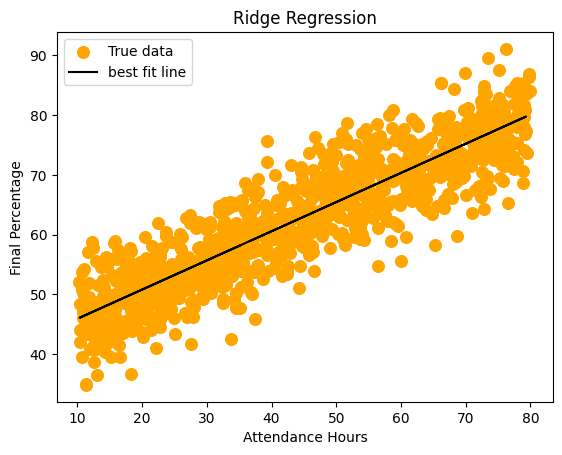

In [20]:
plt.scatter(x,y,color = 'orange', label = 'True data', s = 70)
plt.plot(x_test, y_Pred, color='k', label = 'best fit line')
plt.title('Ridge Regression')
plt.xlabel('Attendance Hours')
plt.ylabel('Final Percentage')
plt.legend()
plt.show()